In [1]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "CMakeLists.txt").exists():
    ROOT = ROOT.parent
PIC, UNIT = ROOT / "build" / "pic_pusher", ROOT / "build" / "pic_unit"
DATA = ROOT / "data" / "pic"
FIG = DATA / "figures"
FIG.mkdir(parents=True, exist_ok=True)
subprocess.run(["cmake", "--build", str(ROOT / "build")], check=True, capture_output=True)


CompletedProcess(args=['cmake', '--build', '/Users/paulvuattier/Desktop/M2/HPC/weeks_NA/boris_pusher/build'], returncode=0, stdout=b'[ 33%] Built target boris_pusher\n[ 66%] Built target pic_pusher\n[100%] Built target pic_unit\n', stderr=b'')

# Hybrid PIC code tests

| # | Test | part tested |
|---|---|---|
| 1 | Ampère on a sine field | field solver | 
| 2 | Faraday on a sine field, $\nabla\cdot\mathbf{B} = 0$ | field solver | 
| 3 | Moments of a known distribution | deposit | 
| 4 | Density conservation | deposit + boundaries | 
| 5 | Energy conservation | whole loop | 


Protons in SI units. Default grid: 64 cells of $\Delta x = 10^{-4}$ m, $B_0 = 1$ T along $z$, $\Delta t = 10^{-10}$ s.

In [2]:
Q, M = 1.602176634e-19, 1.67262192369e-27        # proton charge (C), mass (kg)
load = lambda f: np.genfromtxt(f, delimiter=",", names=True, dtype=None, encoding=None)

def plasma(n0, ppc=20, vth=1e4, nx=64, ny=1, dx=1e-4, dim=1, quiet=False, profile=None, vbulk=None, seed=0):
    # Macro-particles (rows q, m, x, y, z, vx, vy, vz, w) for a plasma of density n0.
    #   quiet: evenly spaced particles (1D); profile(x): density shape; vbulk(x): bulk velocity
    rng = np.random.default_rng(seed)
    N = nx * ny * ppc
    x = (np.arange(N) + 0.5) * dx / ppc if quiet else rng.uniform(0, nx * dx, N)
    y = rng.uniform(0, ny * dx, N) if dim == 2 else np.zeros(N)
    w = n0 * dx**dim / ppc * (profile(x) if profile else np.ones(N))
    v = rng.normal(0, vth, (N, 3)) if vth else np.zeros((N, 3))
    if vbulk:
        v += np.column_stack(vbulk(x))
    return np.column_stack([np.full(N, Q), np.full(N, M), x, y, np.zeros(N), v, w])

def run_pic(name, particles, **options):
    # Run the PIC loop. Returns (diag, grid):
    #   diag: every `stride` steps -> t, K (ion kinetic energy), WdB (magnetic perturbation energy),
    #         Ndep (deposited particle number), Wsum (sum of weights), Bz_mean, max_divB
    #   grid: final E, B, n, v on the grid
    ic, diag, grid = DATA / f"{name}_ic.csv", DATA / f"{name}_diag.csv", DATA / f"{name}_grid.csv"
    np.savetxt(ic, particles, delimiter=",", header="q,m,x,y,z,vx,vy,vz,w", comments="")
    opts = [f"{k}={v}" for k, v in options.items()]
    subprocess.run([PIC, "--run-pic", "/dev/null", ic, *opts, f"diag={diag}", f"grid={grid}"], check=True, capture_output=True)
    return load(diag), load(grid)

def compare_value(label, code, theory, unit=""):
    # one line: value computed by the code next to the theoretical value
    print(f"{label:<48s} code = {code: .6e} {unit:<5s}  theory = {theory: .6e} {unit}")

## Data files


| File | Written by | One row = |
|---|---|---|
| `*_ic.csv` | the notebook (input) | one macro-particle at $t = 0$ |
| `*_particles.csv` | `pic_pusher` (first argument) | one particle at one output time |
| `*_diag.csv` | `pic_pusher diag=` | one output time (global quantities) |
| `*_grid.csv` | `pic_pusher grid=` | one grid point at the end of the run (1D: `i`; 2D: `i, j`) |
| `unit_*.csv` | `pic_unit` | one field component at one grid point |


## show tables

In [3]:
import pandas as pd
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", None)

def show(path, meaning, rows=3):
    # Load a CSV with pandas, list its columns with their meaning, and show the first rows.
    df = pd.read_csv(path)
    print(f"{Path(path).name}: {len(df)} rows x {len(df.columns)} columns")
    display(pd.DataFrame({"meaning": [meaning.get(c, "") for c in df.columns]}, index=df.columns))
    display(df.head(rows))
    return df


# tiny example runs: 1D (8 cells x 4 particles, 20 steps, output every 10) and 2D (4 x 4 cells, 1 step)
ex = plasma(1e24, ppc=4, nx=8, seed=0)
files = {k: DATA / f"example_{k}.csv" for k in ("ic", "particles", "diag", "grid", "ic2d", "grid2d")}
np.savetxt(files["ic"], ex, delimiter=",", header="q,m,x,y,z,vx,vy,vz,w", comments="")
# 2D needs its own particles: there the weight means ions per metre along z, not per m2
np.savetxt(files["ic2d"], plasma(1e24, ppc=4, nx=4, ny=4, dim=2, seed=0), delimiter=",",
           header="q,m,x,y,z,vx,vy,vz,w", comments="")
subprocess.run([PIC, "--run-pic", files["particles"], files["ic"], "nx=8", "steps=20", "stride=10",
                f"diag={files['diag']}", f"grid={files['grid']}"], check=True, capture_output=True)
subprocess.run([PIC, "--run-pic", "/dev/null", files["ic2d"], "dim=2", "nx=4", "ny=4", "steps=1",
                f"grid={files['grid2d']}"], check=True, capture_output=True)
subprocess.run([UNIT, "ampere", "1", "16", DATA / "example_unit.csv"], check=True, capture_output=True)

vel = {f"v{c}": f"velocity {c} (m/s)" for c in "xyz"}
pos = {c: f"position {c} (m)" for c in "xyz"}
show(files["ic"], {"q": "charge (C)", "m": "mass (kg)", **pos, **vel,
                   "w": "weight: real ions per macro-particle (per m2 in 1D, per m in 2D)"})
show(files["particles"], {"pid": "particle index (row of the IC file)", "t": "time (s)", **pos,
                          **{k: v + ", half a step behind x" for k, v in vel.items()}})
show(files["diag"], {"t": "time (s)", "K": "ion kinetic energy, sum 1/2 m w v^2 (J)",
                     "WdB": "magnetic energy of B - <B> (J)", "Ndep": "total deposited on the grid, sum n dV",
                     "Wsum": "total particle weight, sum w (must equal Ndep)", "Bz_mean": "average Bz (T)",
                     "max_divB": "max |div B| (T/m); 0 in 1D", "Px": "total ion momentum x (kg m/s)",
                     "Py": "total ion momentum y (kg m/s)", "Pz": "total ion momentum z (kg m/s)"})
grid_meaning = {"i": "cell index along x", "j": "cell index along y", "x": "node position x (m)",
                "y": "node position y (m)", **{f"E{c}": f"electric field {c} (V/m)" for c in "xyz"},
                **{f"B{c}": f"magnetic field {c} (T)" for c in "xyz"}, "n": "ion density (m^-3)",
                **{f"v{c}": f"ion bulk velocity {c} (m/s)" for c in "xyz"}}
show(files["grid"], grid_meaning)
show(files["grid2d"], grid_meaning)
show(DATA / "example_unit.csv", {"comp": "field component (jy, jz, Bx, ...)", "i": "cell index along x",
                                 "j": "cell index along y (0 in 1D)", "x": "position where it is stored (box length 1)",
                                 "y": "same, along y", "num": "value computed by the code", "exact": "analytic value"});


example_ic.csv: 32 rows x 9 columns


,meaning
q,charge (C)
m,mass (kg)
x,position x (m)
y,position y (m)
z,position z (m)
vx,velocity x (m/s)
vy,velocity y (m/s)
vz,velocity z (m/s)
w,"weight: real ions per macro-particle (per m2 in 1D, per m in 2D)"


,q,m,x,y,z,vx,vy,vz,w
0,1.602177e-19,1.672622e-27,0.000510,0.0,0.0,-1592.250099,5408.455847,2146.591225,2.500000e+19
1,1.602177e-19,1.672622e-27,0.000216,0.0,0.0,3553.727090,-6538.286094,-1296.136337,2.500000e+19
2,1.602177e-19,1.672622e-27,0.000033,0.0,0.0,7839.754701,14934.311452,-12590.655321,2.500000e+19


example_particles.csv: 96 rows x 8 columns


,meaning
pid,particle index (row of the IC file)
t,time (s)
x,position x (m)
y,position y (m)
z,position z (m)
vx,"velocity x (m/s), half a step behind x"
vy,"velocity y (m/s), half a step behind x"
vz,"velocity z (m/s), half a step behind x"


...

,meaning
i,cell index along x
j,cell index along y
x,node position x (m)
y,node position y (m)
Ex,electric field x (V/m)
Ey,electric field y (V/m)
Ez,electric field z (V/m)
Bx,magnetic field x (T)
By,magnetic field y (T)
Bz,magnetic field z (T)


,i,j,x,y,Ex,Ey,Ez,Bx,By,Bz,n,vx,vy,vz
0,0,0,0.0000,0.0,-2295.577632,-2552.636670,-0.0,0.0,0.0,0.998094,1.635534e+24,-253.322220,-953.171198,-1619.468055
1,1,0,0.0001,0.0,-3465.690366,485.032724,-0.0,0.0,0.0,1.001607,1.043960e+24,2475.006765,5544.326463,-287.427047
2,2,0,0.0002,0.0,-709.700664,-375.982210,-0.0,0.0,0.0,1.001422,1.057673e+24,3176.087838,1387.054269,-5832.885932


example_unit.csv: 32 rows x 7 columns


,meaning
comp,"field component (jy, jz, Bx, ...)"
i,cell index along x
j,cell index along y (0 in 1D)
x,position where it is stored (box length 1)
y,"same, along y"
num,value computed by the code
exact,analytic value


,comp,i,j,x,y,num,exact
0,jy,0,0,0.0000,0.0,-6.242890e+00,-6.283185
1,jz,0,0,0.0000,0.0,1.776357e-15,-0.000000
2,jy,1,0,0.0625,0.0,-5.767679e+00,-5.804906


Grid positions:  x and y in the grid files is the position of the node $i$.

Each field component is stored at its own offset from it: in 1D, $E_x$, $B_y$, $B_z$ sit half a cell to the right, at $x + \Delta x/2$. In 2D, $E_x$ and $B_y$ are on the x-edges, $E_y$ and $B_x$ on the y-edges, and $B_z$ at the cell centre. 

The density and bulk velocity are on the nodes.

## Test 1 - Ampère: $\mu_0\mathbf{j} = \nabla\times\mathbf{B}$

Why --> Check curl is correct cause current --> E through Ohm's law

How --> Compare exact curl with Ampère pic apllied on a known field

- 1D: $B_y = \cos kx$, $B_z = \sin kx$ → $\mu_0 j_y = -k\cos kx$, $\mu_0 j_z = -k\sin kx$;
- 2D: $B_x = \cos ky$, $B_y = \cos kx$, $B_z = \sin kx\cos ky$ --> all three components of $\mu_0\mathbf{j}$.


1D Ampere jy: amplitude                          code =  6.273097e+00        theory =  6.283185e+00 
1D Ampere jz: amplitude                          code =  6.273097e+00        theory =  6.283185e+00 
2D Ampere jx: amplitude                          code =  6.242890e+00        theory =  6.283185e+00 
2D Ampere jy: amplitude                          code =  6.242890e+00        theory =  6.283185e+00 
2D Ampere jz: amplitude                          code =  1.254619e+01        theory =  1.256637e+01 


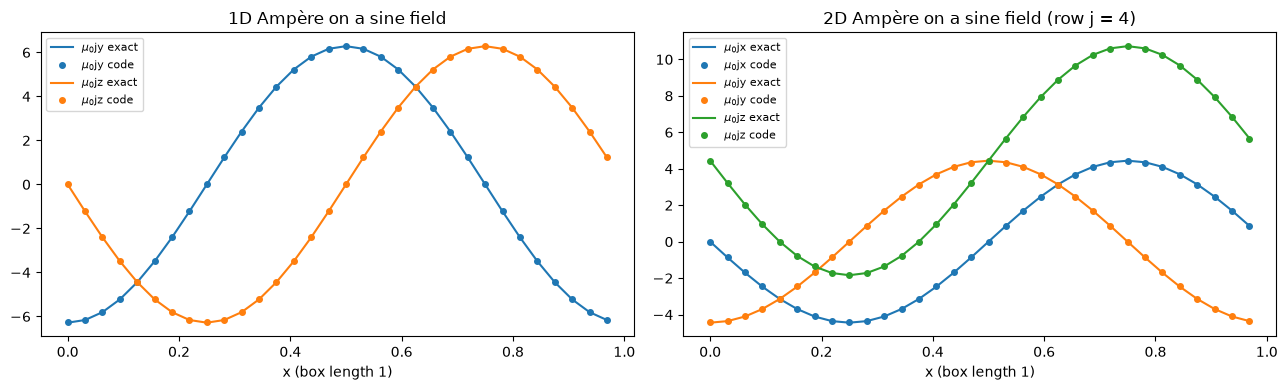

In [4]:
def unit(op, dim, nx=32):
    out = DATA / f"unit_{op}_{dim}d.csv"
    subprocess.run([UNIT, op, str(dim), str(nx), out], check=True, capture_output=True)
    return load(out)

def compare_field(d, name):
    # amplitude of each component (around its mean), code vs exact
    for c in sorted(set(d["comp"])):
        s = d["comp"] == c
        base = d["exact"][s].mean()
        compare_value(f"{name} {c}: amplitude", np.abs(d["num"][s] - base).max(), np.abs(d["exact"][s] - base).max())

for dim in (1, 2):
    compare_field(unit("ampere", dim), f"{dim}D Ampere")

# mu0 j, code vs exact: 1D along x, and 2D along the row j = 4 (all three components are non-zero there)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, dim, comps in [(ax[0], 1, ("jy", "jz")), (ax[1], 2, ("jx", "jy", "jz"))]:
    d = unit("ampere", dim)
    for c, col in zip(comps, ("C0", "C1", "C2")):
        s = (d["comp"] == c) & (d["j"] == (4 if dim == 2 else 0))
        a.plot(d["x"][s], d["exact"][s], col + "-", label=f"$\\mu_0${c} exact")
        a.plot(d["x"][s], d["num"][s], col + "o", ms=4, label=f"$\\mu_0${c} code")
    a.set(title=f"{dim}D Ampère on a sine field" + (" (row j = 4)" if dim == 2 else ""),
          xlabel="x (box length 1)"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "test1_ampere.png", dpi=110); plt.show()

## Test 2 - Faraday: $\partial_t\mathbf{B} = -\nabla\times\mathbf{E}$, and $\nabla\cdot\mathbf{B} = 0$

why --> check faraday cause B depends on it

how --> 
- One Faraday step on known sine fields $E_x$, $E_y$, $E_z$, compared with the exact $\mathbf{B}_{\rm new} = \mathbf{B}_{\rm old} - \Delta t\,\nabla\times\mathbf{E}$.
- 2000 steps with a fixed $E_z = E_0\sin kx\sin ky$ on a 2D grid: $B_x$ and $B_y$ grow from zero, and  follow $\max|\nabla\cdot\mathbf{B}|$.


1D Faraday, change of By: amplitude              code =  6.242890e-03        theory =  6.252930e-03 
1D Faraday, change of Bz: amplitude              code =  6.242890e-03        theory =  6.252930e-03 
2D Faraday, change of Bx: amplitude              code =  6.242890e-03        theory =  6.252930e-03 
2D Faraday, change of By: amplitude              code =  6.242890e-03        theory =  6.252930e-03 
2D Faraday, change of Bz: amplitude              code =  1.248578e-02        theory =  1.250586e-02 
largest |Bx|, |By| after 2000 steps              code =  3.901806e-01 T      theory =  3.926991e-01 T
div B (relative to |B|/dx)                       code =  5.869644e-14        theory =  0.000000e+00 


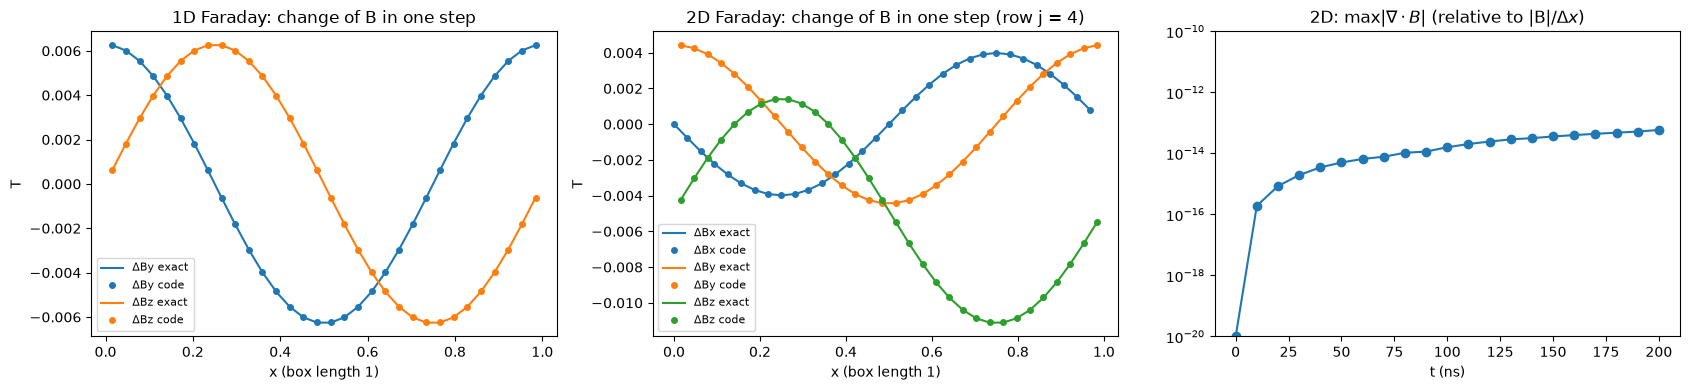

In [5]:
for dim in (1, 2):
    compare_field(unit("faraday", dim), f"{dim}D Faraday, change of")   # change of B in one step

dummy = plasma(0.0, ppc=1, nx=1)                          # no plasma, just the field solver
diag, grid = run_pic("divb", dummy, dim=2, nx=32, ny=32, field="sine", freeze="E", B="0,0,0", steps=2000, stride=100)
Bscale = max(np.abs(grid["Bx"]).max(), np.abs(grid["By"]).max()) / 1e-4
divb = diag["max_divB"] / Bscale
k_box = 2 * np.pi / (32 * 1e-4)                            # sine wavenumber of the 2D box
compare_value("largest |Bx|, |By| after 2000 steps", Bscale * 1e-4, 2000 * 1e-10 * k_box * 1e3, "T")  # t k E0
compare_value("div B (relative to |B|/dx)", divb.max(), 0.0)

# change of B in one Faraday step, code vs exact: 1D along x, and 2D along the row j = 4 (where all components changes-
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for a, dim, comps in [(ax[0], 1, ("By", "Bz")), (ax[1], 2, ("Bx", "By", "Bz"))]:
    d = unit("faraday", dim)
    for c, col in zip(comps, ("C0", "C1", "C2")):
        s = (d["comp"] == c) & (d["j"] == (4 if dim == 2 else 0))
        base = d["exact"][d["comp"] == c].mean()                # B before the step
        a.plot(d["x"][s], d["exact"][s] - base, col + "-", label=f"$\\Delta${c} exact")
        a.plot(d["x"][s], d["num"][s] - base, col + "o", ms=4, label=f"$\\Delta${c} code")
    a.set(title=f"{dim}D Faraday: change of B in one step" + (" (row j = 4)" if dim == 2 else ""),
          xlabel="x (box length 1)", ylabel="T"); a.legend(fontsize=8)
ax[2].semilogy(diag["t"] * 1e9, divb + 1e-20, "o-")
ax[2].set(title=r"2D: max|$\nabla\cdot B$| (relative to |B|/$\Delta x$)", xlabel="t (ns)", ylim=(1e-20, 1e-10))
fig.tight_layout(); fig.savefig(FIG / "test2_faraday.png", dpi=110); plt.show()

## Test 3 - Moments: deposit of a known distribution

Why --> deposit particles = grid density & bulk velocity use by solver --> find profile particles were drawn from

How --> use known density and velocity profile,
$$n(x) = \tfrac{n_0}{2}\,(1 + \tfrac12\sin kx),\qquad v_x = V_0\cos kx,\qquad v_y = V_0/2,$$
deposit once  and compare with the profile.
- quiet start --> particles evenly spaced 
- random start--> random positions, 16 per cell


quiet start: largest density                     code =  7.497977e+23 m-3    theory =  7.500000e+23 m-3
quiet start: smallest density                    code =  2.502023e+23 m-3    theory =  2.500000e+23 m-3
quiet start: largest v_x                         code =  9.991908e+03 m/s    theory =  1.000000e+04 m/s
quiet start: v_y (constant V0/2)                 code =  5.000000e+03 m/s    theory =  5.000000e+03 m/s
random start: density noise                      code =  2.074635e-01        theory =  2.500000e-01 


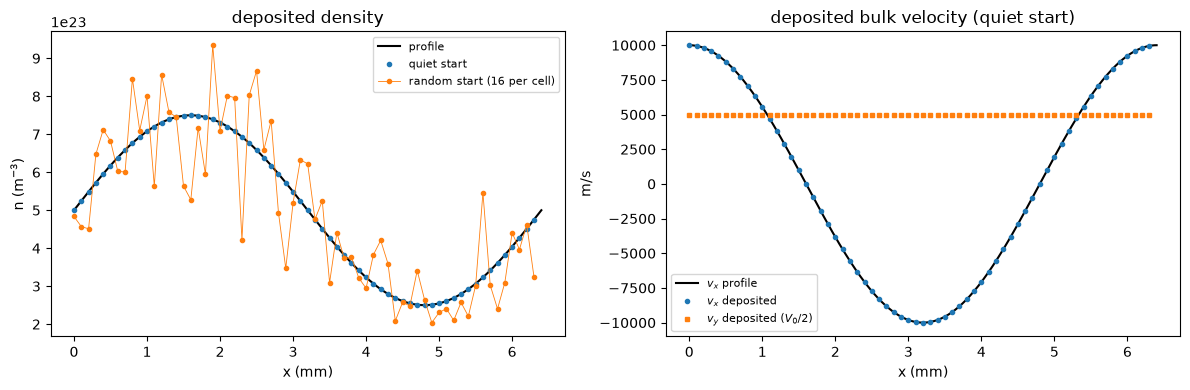

In [6]:
n0, V0, L = 1e24, 1e4, 64 * 1e-4
k = 2 * np.pi / L
profile = lambda x: 0.5 * (1 + 0.5 * np.sin(k * x))
vbulk = lambda x: (V0 * np.cos(k * x), np.full_like(x, V0 / 2), np.zeros_like(x))

_, quiet = run_pic("moments_quiet", plasma(n0, ppc=8, vth=0, quiet=True, profile=profile, vbulk=vbulk), steps=0)
_, noisy = run_pic("moments_random", plasma(n0, ppc=16, vth=0, profile=profile, vbulk=vbulk, seed=3), steps=0)

err_n = np.abs(quiet["n"] / (n0 * profile(quiet["x"])) - 1).max()
err_v = np.abs(quiet["vx"] - V0 * np.cos(k * quiet["x"])).max() / V0
err_vy = np.abs(quiet["vy"] / (V0 / 2) - 1).max()
noise = np.std(noisy["n"] / (n0 * profile(noisy["x"])) - 1)

compare_value("quiet start: largest density", quiet["n"].max(), n0 * profile(quiet["x"]).max(), "m-3")
compare_value("quiet start: smallest density", quiet["n"].min(), n0 * profile(quiet["x"]).min(), "m-3")
compare_value("quiet start: largest v_x", quiet["vx"].max(), (V0 * np.cos(k * quiet["x"])).max(), "m/s")
compare_value("quiet start: v_y (constant V0/2)", quiet["vy"].mean(), V0 / 2, "m/s")
compare_value("random start: density noise", noise, 1 / np.sqrt(16))    # theory: about 1/sqrt(particles per cell)

xx = np.linspace(0, L, 400)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xx * 1e3, n0 * profile(xx), "k-", label="profile")
ax[0].plot(quiet["x"] * 1e3, quiet["n"], "o", ms=3, label="quiet start")
ax[0].plot(noisy["x"] * 1e3, noisy["n"], ".-", lw=0.6, label="random start (16 per cell)")
ax[0].set(title="deposited density", xlabel="x (mm)", ylabel=r"n (m$^{-3}$)"); ax[0].legend(fontsize=8)
ax[1].plot(xx * 1e3, V0 * np.cos(k * xx), "k-", label="$v_x$ profile")
ax[1].plot(quiet["x"] * 1e3, quiet["vx"], "o", ms=3, label="$v_x$ deposited")
ax[1].plot(quiet["x"] * 1e3, quiet["vy"], "s", ms=3, label="$v_y$ deposited ($V_0/2$)")
ax[1].set(title="deposited bulk velocity (quiet start)", xlabel="x (mm)", ylabel="m/s"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "test3_moments.png", dpi=110); plt.show()

## Test 4 - Density conservation

Why --> don't introduce matter + finite space (or looped) = density should remain constant

In a periodic box the number of ions never changes. The deposit must share each particle's weight between its grid nodes without losing any (course notes eq. 10), and particles leaving one side must come back on the other. If density leaked, $1/n$ in Ohm's law would make the fields drift too.

**How.**

- plasma ($n_0 = 10^{24}$ m⁻³, $v_{th} = 10^4$ m/s, 40 particles per cell). At each output  compare the total deposited on the grid, $\sum_i n_i\Delta x$, with the total weight of the particles, $\sum_p w_p$.
- uniform cold plasma at rest --> exact equilibrium: nothing move, and $n$  stays uniform with $\mathbf{E} = 0$.


total on the grid after 2000 steps               code =  6.400000e+21        theory =  6.400000e+21 
total on the grid at the start                   code =  6.400000e+21        theory =  6.400000e+21 
cold plasma: largest density after 2000 steps    code =  1.000000e+24 m-3    theory =  1.000000e+24 m-3
cold plasma: smallest density after 2000 steps   code =  1.000000e+24 m-3    theory =  1.000000e+24 m-3
cold plasma: largest |E|                         code =  0.000000e+00 V/m    theory =  0.000000e+00 V/m


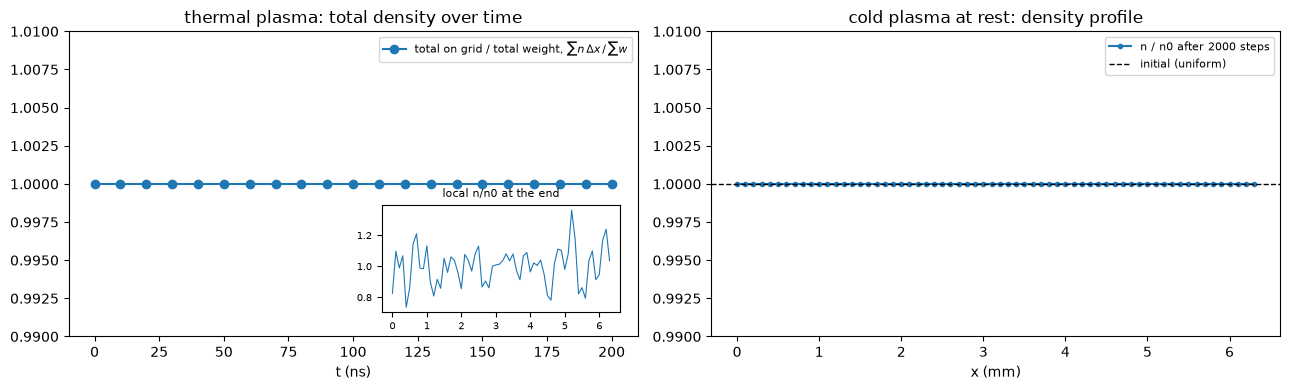

In [7]:
diag, grid = run_pic("density", plasma(1e24, ppc=40, seed=4), steps=2000, stride=100)
leak = np.abs(diag["Ndep"] / diag["Wsum"] - 1)
compare_value("total on the grid after 2000 steps", diag["Ndep"][-1], diag["Wsum"][-1])  # theory: sum of weights
compare_value("total on the grid at the start", diag["Ndep"][0], diag["Wsum"][0])

_, eq = run_pic("equilibrium", plasma(1e24, ppc=16, vth=0, quiet=True), steps=2000, stride=500)
dev = np.abs(eq["n"] / 1e24 - 1).max()
emax = max(np.abs(eq[c]).max() for c in ("Ex", "Ey", "Ez"))
compare_value("cold plasma: largest density after 2000 steps", eq["n"].max(), 1e24, "m-3")
compare_value("cold plasma: smallest density after 2000 steps", eq["n"].min(), 1e24, "m-3")
compare_value("cold plasma: largest |E|", emax, 0.0, "V/m")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# case 1: thermal plasma -- local density is noisy, but the total never changes
ax[0].plot(diag["t"] * 1e9, diag["Ndep"] / diag["Wsum"], "o-", label=r"total on grid / total weight, $\sum n\,\Delta x \,/\, \sum w$")
ax[0].set(title="thermal plasma: total density over time", xlabel="t (ns)", ylim=(0.99, 1.01)); ax[0].legend(fontsize=8)
ax0 = ax[0].inset_axes([0.55, 0.08, 0.42, 0.35])
ax0.plot(grid["x"] * 1e3, grid["n"] / 1e24, lw=0.8); ax0.set_title("local n/n0 at the end", fontsize=8)
ax0.tick_params(labelsize=7)
# case 2: cold plasma at rest -- nothing moves, density stays exactly uniform
ax[1].plot(eq["x"] * 1e3, eq["n"] / 1e24, "o-", ms=3, label="n / n0 after 2000 steps")
ax[1].axhline(1, color="k", ls="--", lw=1, label="initial (uniform)")
ax[1].set(title="cold plasma at rest: density profile", xlabel="x (mm)", ylim=(0.99, 1.01)); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "test4_density.png", dpi=110); plt.show()

## Test 5 - Energy conservation

Why --> Energy checks the whole loop at once: the ions give energy to the magnetic field and take it back. With cold electrons, the total
$$\mathcal{E} = \underbrace{\sum_p \tfrac12 m w_p|\mathbf{v}_p|^2}_{\text{ions}} + \underbrace{\int \frac{|\mathbf{B} - \langle\mathbf{B}\rangle|^2}{2\mu_0}\,dV}_{\text{magnetic perturbation}}$$
must stay constant, up to a slow heating by particle noise.

How -->
- freeze fields --> only gather and Boris act --> so the ion energy must be  conserved.
- different densities --> test stability
- same test in 2D with
  - fields vary along $x$ and $y$ (32 × 32 cells) instead of $x$ only
  - $\mathbf{B}_0 = (0.5, 0.3, 1)$ T is tilted into the plane  --> $B_x$ and $B_y$  change too --> faster waves appear 
  -  smaller time step: $\Delta t = 3\times10^{-12}$ s s for faster waves


In [8]:
diag, _ = run_pic("energy_frozen", plasma(1e24, seed=5), steps=2000, stride=100, freeze="EB")
change = np.abs(diag["K"] / diag["K"][0] - 1).max()
compare_value("fields fixed: ion energy at the end", diag["K"][-1], diag["K"][0], "J")   # theory: unchanged

runs = {}
for n in [1e22, 1e23, 1e24]:
    diag, _ = run_pic(f"energy_n{n:.0e}", plasma(n, seed=6), steps=2000, stride=20)
    runs[n] = diag
    energy = diag["K"] + diag["WdB"]
    compare_value(f"n = {n:.0e}: total energy at the end", energy[-1], energy[0], "J")
E24 = runs[1e24]["K"] + runs[1e24]["WdB"]
E22 = runs[1e22]["K"] + runs[1e22]["WdB"]
print("-> n = 1e24 (S = 0.5): stable, energy close to its start value; n = 1e22 (S = 49): blows up, as predicted")

d2, _ = run_pic("energy_2d", plasma(1e24, ppc=16, nx=32, ny=32, dim=2, seed=8),
                dim=2, nx=32, ny=32, dt=3e-12, steps=3000, stride=100, B="0.5,0.3,1")
E2 = d2["K"] + d2["WdB"]
compare_value("2D, tilted B0: total energy at the end", E2[-1], E2[0], "J")
compare_value("2D, tilted B0: div B (relative)", d2["max_divB"].max() * 1e-4, 0.0)

fields fixed: ion energy at the end              code =  1.666749e+03 J      theory =  1.666749e+03 J
n = 1e+22: total energy at the end               code =  1.762529e+04 J      theory =  1.613811e+01 J


n = 1e+23: total energy at the end               code =  5.323325e+02 J      theory =  1.613811e+02 J
n = 1e+24: total energy at the end               code =  1.671997e+03 J      theory =  1.613811e+03 J
-> n = 1e24 (S = 0.5): stable, energy close to its start value; n = 1e22 (S = 49): blows up, as predicted


2D, tilted B0: total energy at the end           code =  2.602839e+00 J      theory =  2.573035e+00 J
2D, tilted B0: div B (relative)                  code =  8.685674e-15        theory =  0.000000e+00 


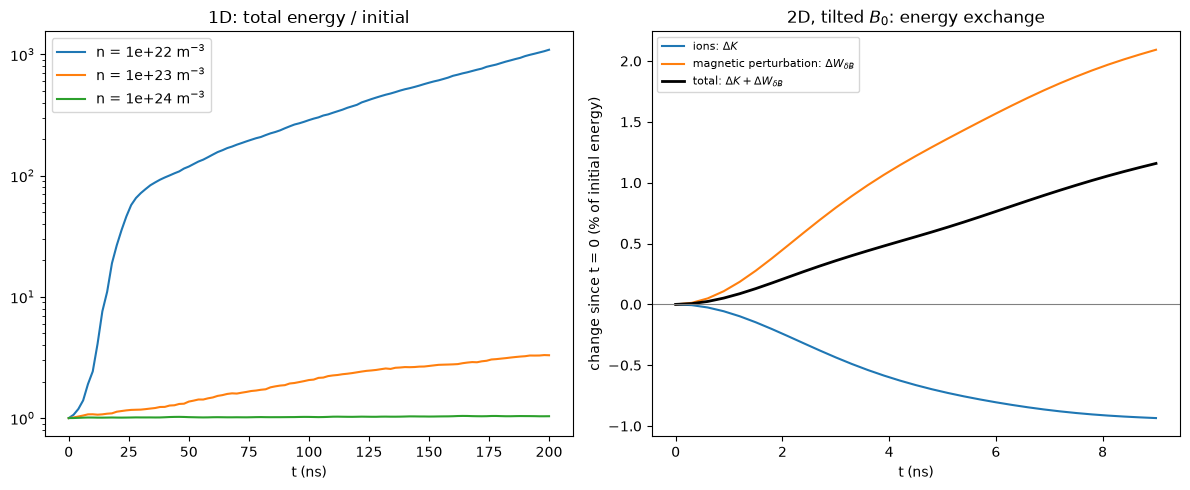

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
for n, diag in runs.items():
    energy = diag["K"] + diag["WdB"]
    ax[0].semilogy(diag["t"] * 1e9, energy / energy[0], label=f"n = {n:.0e} m$^{{-3}}$")
ax[0].set(title="1D: total energy / initial", xlabel="t (ns)"); ax[0].legend()
# 2D: the CHANGE of each energy since t = 0 (in % of the initial total), so the exchange is visible
pct = lambda e: 100 * (e - e[0]) / E2[0]
ax[1].plot(d2["t"] * 1e9, pct(d2["K"]), label="ions: $\\Delta K$")
ax[1].plot(d2["t"] * 1e9, pct(d2["WdB"]), label="magnetic perturbation: $\\Delta W_{\\delta B}$")
ax[1].plot(d2["t"] * 1e9, pct(E2), "k", lw=2, label="total: $\\Delta K + \\Delta W_{\\delta B}$")
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set(title="2D, tilted $B_0$: energy exchange", xlabel="t (ns)", ylabel="change since t = 0 (% of initial energy)"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "test5_energy.png", dpi=110); plt.show()

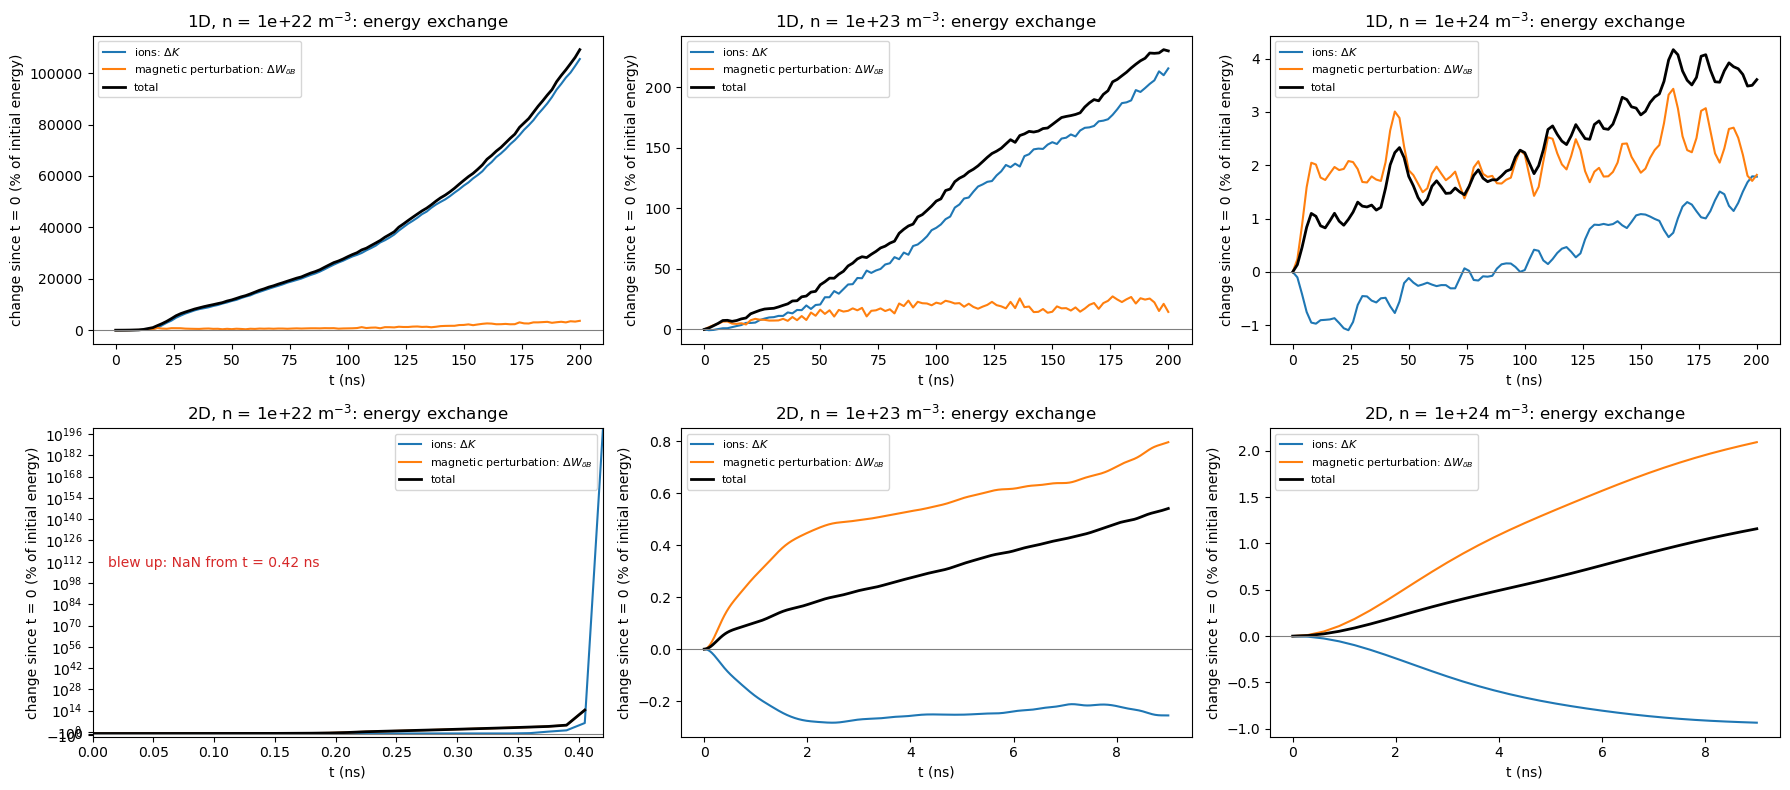

In [28]:
# energy exchange at each density: change of each energy since t = 0, in % of the initial total
# 2D runs: same setup as the 2D run above (tilted B0, dt = 3e-12 s, 3000 steps); n = 1e24 is d2
runs2d = {}
for n in [1e22, 1e23]:
    runs2d[n], _ = run_pic(f"energy_2d_n{n:.0e}", plasma(n, ppc=16, nx=32, ny=32, dim=2, seed=8),
                           dim=2, nx=32, ny=32, dt=3e-12, steps=3000, stride=5, B="0.5,0.3,1")   # dense output: see a blow-up
runs2d[1e24] = d2

fig, ax = plt.subplots(2, 3, figsize=(18, 8))
for row, (dim, cases) in enumerate([("1D", runs), ("2D", runs2d)]):
    for a, (n, diag) in zip(ax[row], cases.items()):
        E0_tot = diag["K"][0] + diag["WdB"][0]
        pct = lambda e: 100 * (e - e[0]) / E0_tot
        a.plot(diag["t"] * 1e9, pct(diag["K"]), label="ions: $\\Delta K$")
        a.plot(diag["t"] * 1e9, pct(diag["WdB"]), label="magnetic perturbation: $\\Delta W_{\\delta B}$")
        a.plot(diag["t"] * 1e9, pct(diag["K"] + diag["WdB"]), "k", lw=2, label="total")
        a.axhline(0, color="gray", lw=0.8)
        bad = ~np.isfinite(diag["K"] + diag["WdB"])
        if bad.any():                                   #  run blew up: fields and energies became NaN
            t_nan = diag["t"][bad][0] * 1e9
            a.set_xlim(0, t_nan)
            a.set_yscale("symlog", linthresh=1)        # growth over hundreds of decades: log scale
            a.set_ylim(bottom=-10)
            a.text(0.03, 0.55, f"blew up: NaN from t = {t_nan:.2f} ns", transform=a.transAxes, color="C3")
        a.set(title=f"{dim}, n = {n:.0e} m$^{{-3}}$: energy exchange", xlabel="t (ns)",
              ylabel="change since t = 0 (% of initial energy)")
        a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "test5_exchange.png", dpi=110); plt.show()